In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Satellite link budget analyzer

In [9]:
import math
def linear_to_db(ratio):
    return 10*math.log(ratio)

def db_to_linear(db_value):
    return 10**(db_value/10)

print("testing db conversions")
print("db value for 100:", linear_to_db(100))
print("linear value for 100:", db_to_linear(100))

testing db conversions
db value for 100: 46.05170185988092
linear value for 100: 10000000000.0


In [10]:
import math
def free_space_loss(d_km,f_ghz):
    loss  = 20*math.log10(f_ghz) +20*math.log10(d_km) + 92.4
    return loss
print("📡 FREE SPACE PATH LOSS CALCULATIONS")
print("="*50)

# GEO Satellite (ISRO GSAT)
geo_loss = free_space_loss(36000, 6.0)
print(f"GEO Satellite (36,000 km, 6 GHz C-band):")
print(f"  Loss = {geo_loss:.1f} dB")
print(f"  That's {db_to_linear(geo_loss):.1e} times weaker!")

# LEO Satellite
leo_loss = free_space_loss(600, 6.0)
print(f"\nLEO Satellite (600 km, 6 GHz C-band):")
print(f"  Loss = {leo_loss:.1f} dB")
print(f"  That's {db_to_linear(leo_loss):.1e} times weaker")

difference = geo_loss - leo_loss
print(f"\n📊 Comparison:")
print(f"  GEO has {difference:.1f} dB MORE loss than LEO")
print(f"  GEO signal is {db_to_linear(difference):.0f} times WEAKER than LEO")


📡 FREE SPACE PATH LOSS CALCULATIONS
GEO Satellite (36,000 km, 6 GHz C-band):
  Loss = 199.1 dB
  That's 8.1e+19 times weaker!

LEO Satellite (600 km, 6 GHz C-band):
  Loss = 163.5 dB
  That's 2.3e+16 times weaker

📊 Comparison:
  GEO has 35.6 dB MORE loss than LEO
  GEO signal is 3600 times WEAKER than LEO


In [22]:
def satellite_link_budget(d,f,Pt,Gt,Gr,A_loss = 2):
    total_loss = free_space_loss(d,f)+A_loss
    Pr = Pt+Gt+Gr-total_loss
    required_power = -80
    link_margin = Pr - required_power
    feasible = link_margin>3
    return {
        'distance_km': d,
        'frequency_GHz': f,
        'transmit_power_dBm': Pt,
        'transmit_gain_dBi': Gt,
        'receive_gain_dBi':Gr,
        'free_space_loss_dB': round(free_space_loss(d,f), 1),
        'additional_loss_dB': A_loss,
        'total_loss_dB': round(total_loss, 1),
        'received_power_dBm': round(Pr, 1),
        'required_power_dBm': required_power,
        'link_margin_dB': round(link_margin, 1),
        'feasible': 'YES' if feasible else 'NO'
    }

gsat_result = satellite_link_budget(
    d=36000,
    f=6.0,
    Pt=40,
    Gt=30,
    Gr=45
)
display_link_budget(gsat_result)

📡 SATELLITE LINK BUDGET: Satellite

📊 SYSTEM PARAMETERS:
  Satellite Distance: 36,000 km
  Frequency: 6.0 GHz
  Transmit Power: 40 dBm (10.0 W)
  Satellite Antenna Gain: 30 dBi
  Ground Station Gain: 45 dBi

📉 LOSS CALCULATIONS:
  Free Space Path Loss: 199.1 dB
  Additional Losses (atmospheric, etc.): 2 dB
  Total Loss: 201.1 dB

⚡ POWER BUDGET:
  Transmitted Power: 40 dBm
  Total Antenna Gain: 75 dBi
  Received Power: -86.1 dBm

🔗 LINK ANALYSIS:
  Required Power: -80 dBm
  Link Margin: -6.1 dB
  Status: ⚠️  MARGINAL/INFEASIBLE
  Needed Improvement: 9.1 dB


In [21]:
def display_link_budget(result, satellite_name="Satellite"):
    """
    Display link budget results in professional format
    """
    print("="*60)
    print(f"📡 SATELLITE LINK BUDGET: {satellite_name}")
    print("="*60)
    
    # System Parameters
    print("\n📊 SYSTEM PARAMETERS:")
    print(f"  Satellite Distance: {result['distance_km']:,.0f} km")
    print(f"  Frequency: {result['frequency_GHz']} GHz")
    print(f"  Transmit Power: {result['transmit_power_dBm']} dBm ({db_to_linear(result['transmit_power_dBm']-30):.1f} W)")
    print(f"  Satellite Antenna Gain: {result['transmit_gain_dBi']} dBi")
    print(f"  Ground Station Gain: {result['receive_gain_dBi']} dBi")
    
    # Loss Calculations
    print("\n📉 LOSS CALCULATIONS:")
    print(f"  Free Space Path Loss: {result['free_space_loss_dB']} dB")
    print(f"  Additional Losses (atmospheric, etc.): {result['additional_loss_dB']} dB")
    print(f"  Total Loss: {result['total_loss_dB']} dB")
    
    # Power Budget
    print("\n⚡ POWER BUDGET:")
    print(f"  Transmitted Power: {result['transmit_power_dBm']} dBm")
    print(f"  Total Antenna Gain: {result['transmit_gain_dBi'] + result['receive_gain_dBi']} dBi")
    print(f"  Received Power: {result['received_power_dBm']} dBm")
    
    # Link Analysis
    print("\n🔗 LINK ANALYSIS:")
    print(f"  Required Power: {result['required_power_dBm']} dBm")
    print(f"  Link Margin: {result['link_margin_dB']} dB")
    
    # Feasibility with emoji
    if result['feasible'] == 'YES':
        print(f"  Status: ✅ FEASIBLE (Good margin)")
    else:
        print(f"  Status: ⚠️  MARGINAL/INFEASIBLE")
        needed = 3 - result['link_margin_dB']
        print(f"  Needed Improvement: {needed:.1f} dB")
    
    print("="*60)

# Also add this helper function if not already defined
def db_to_linear(db_value):
    """Convert dB to linear power ratio"""
    return 10 ** (db_value / 10)

In [23]:
def compare_satellites(satellite_list):
    """
    Compare multiple satellite configurations
    """
    print("="*70)
    print("📡 COMPARATIVE SATELLITE LINK ANALYSIS")
    print("="*70)
    
    print(f"\n{'Satellite':<15} {'Freq (GHz)':<12} {'Rx Power (dBm)':<16} {'Margin (dB)':<12} {'Status':<10}")
    print("-"*70)
    
    for sat in satellite_list:
        name = sat['name']
        result = satellite_link_budget(**sat['params'])
        
        # Status with color indicator
        status = "✅" if result['feasible'] == 'YES' else "⚠️ "
        
        print(f"{name:<15} {result['frequency_GHz']:<12.1f} {result['received_power_dBm']:<16.1f} {result['link_margin_dB']:<12.1f} {status:<10}")
    
    print("="*70)

# Example usage
satellites = [
    {
        'name': 'GSAT-30',
        'params': {'d': 36000, 'f': 6.0, 'Pt': 40, 'Gt': 30, 'Gr': 45}
    },
    {
        'name': 'IRNSS-1G',
        'params': {'d': 36000, 'f': 1.5, 'Pt': 32, 'Gt': 28, 'Gr': 45}
    },
    {
        'name': 'SCATSAT-1',
        'params': {'d': 36000, 'f': 13.5, 'Pt': 42, 'Gt': 32, 'Gr': 45}
    }
]

compare_satellites(satellites)

📡 COMPARATIVE SATELLITE LINK ANALYSIS

Satellite       Freq (GHz)   Rx Power (dBm)   Margin (dB)  Status    
----------------------------------------------------------------------
GSAT-30         6.0          -86.1            -6.1         ⚠️        
IRNSS-1G        1.5          -84.0            -4.0         ⚠️        
SCATSAT-1       13.5         -89.1            -9.1         ⚠️        


In [24]:
# Cell 5: Engineering Analysis and Recommendations

def analyze_link_improvements(base_result):
    """
    Suggest engineering improvements for a marginal link
    """
    print("📊 LINK BUDGET ANALYSIS REPORT")
    print("="*60)
    
    if base_result['feasible'] == 'YES':
        print("✅ Link is feasible with good margin.")
        print(f"   Margin: {base_result['link_margin_dB']:.1f} dB")
        return
    
    print("⚠️  Link is marginal or infeasible!")
    print(f"   Current margin: {base_result['link_margin_dB']:.1f} dB")
    print(f"   Required: > 3 dB")
    print(f"   Shortfall: {3 - base_result['link_margin_dB']:.1f} dB")
    
    print("\n🔧 RECOMMENDED IMPROVEMENTS:")
    
    # Calculate needed improvement
    needed_dB = 3 - base_result['link_margin_dB']
    
    print(f"1. Increase ground station antenna gain by {needed_dB:.1f} dB")
    current_gr = base_result['receive_gain_dBi']
    new_gr = current_gr + needed_dB
    print(f"   Current: {current_gr} dBi → Target: {new_gr:.1f} dBi")
    
    print(f"\n2. Increase satellite transmit power by {needed_dB:.1f} dB")
    current_pt = base_result['transmit_power_dBm']
    new_pt = current_pt + needed_dB
    power_ratio = db_to_linear(needed_dB)
    print(f"   Current: {current_pt} dBm → Target: {new_pt:.1f} dBm")
    print(f"   That's {power_ratio:.1f}× more power")
    
    print(f"\n3. Reduce system losses")
    print(f"   Improve receiver sensitivity")
    print(f"   Better modulation/coding schemes")

# Run analysis on your GSAT result
analyze_link_improvements(gsat_result)




📊 LINK BUDGET ANALYSIS REPORT
⚠️  Link is marginal or infeasible!
   Current margin: -6.1 dB
   Required: > 3 dB
   Shortfall: 9.1 dB

🔧 RECOMMENDED IMPROVEMENTS:
1. Increase ground station antenna gain by 9.1 dB
   Current: 45 dBi → Target: 54.1 dBi

2. Increase satellite transmit power by 9.1 dB
   Current: 40 dBm → Target: 49.1 dBm
   That's 8.1× more power

3. Reduce system losses
   Improve receiver sensitivity
   Better modulation/coding schemes

✅ REAL ENGINEERING WORK COMPLETED!


In [25]:
# Cell 7: ISRO Satellite Database and Analysis

ISRO_SATELLITE_DB = {
    'GSAT-30': {
        'description': 'Telecommunication Satellite',
        'parameters': {
            'd': 36000,    # GEO orbit
            'f': 6.0,      # C-band
            'Pt': 40,      # 10W transmit
            'Gt': 30,      # Medium gain antenna
            'Gr': 45       # Standard ground station
        }
    },
    'IRNSS-1G': {
        'description': 'Navigation Satellite',
        'parameters': {
            'd': 36000,    # GEO orbit
            'f': 1.5,      # L-band
            'Pt': 32,      # 1.6W transmit (lower for navigation)
            'Gt': 28,      # Different antenna pattern
            'Gr': 45
        }
    },
    'RISAT-2B': {
        'description': 'Radar Imaging Satellite',
        'parameters': {
            'd': 600,      # LEO orbit (imaging satellites are lower)
            'f': 3.1,      # S-band
            'Pt': 38,      # 6.3W
            'Gt': 25,      # SAR antenna
            'Gr': 45
        }
    },
    'SCATSAT-1': {
        'description': 'Ocean Monitoring Satellite',
        'parameters': {
            'd': 720,      # LEO orbit
            'f': 13.5,     # Ku-band (high resolution)
            'Pt': 42,      # 16W (higher for Ku-band)
            'Gt': 32,      # High gain for Ku-band
            'Gr': 45
        }
    }
}

print("📡 ISRO SATELLITE FLEET LINK BUDGET ANALYSIS")
print("="*70)

# Analyze all satellites
all_results = []
for name, data in ISRO_SATELLITE_DB.items():
    print(f"\n🔍 Analyzing {name} ({data['description']})...")
    result = satellite_link_budget(**data['parameters'])
    result['name'] = name
    all_results.append(result)
    display_link_budget(result, name)

# Summary table
print("\n" + "="*70)
print("📊 SUMMARY: ISRO SATELLITE LINK PERFORMANCE")
print("="*70)

print(f"\n{'Satellite':<12} {'Orbit':<8} {'Band':<8} {'Rx Power':<10} {'Margin':<10} {'Status':<10}")
print("-"*70)

for result in all_results:
    # Determine orbit type
    if result['distance_km'] > 35000:
        orbit = 'GEO'
    elif result['distance_km'] > 5000:
        orbit = 'MEO'
    else:
        orbit = 'LEO'
    
    # Determine frequency band
    freq = result['frequency_GHz']
    if freq < 2:
        band = 'L'
    elif freq < 4:
        band = 'S'
    elif freq < 8:
        band = 'C'
    else:
        band = 'Ku'
    
    status = "✅ Good" if result['feasible'] == 'YES' else "⚠️ Marginal"
    
    print(f"{result['name']:<12} {orbit:<8} {band:<8} {result['received_power_dBm']:<10.1f} {result['link_margin_dB']:<10.1f} {status:<10}")

print("="*70)

📡 ISRO SATELLITE FLEET LINK BUDGET ANALYSIS

🔍 Analyzing GSAT-30 (Telecommunication Satellite)...
📡 SATELLITE LINK BUDGET: GSAT-30

📊 SYSTEM PARAMETERS:
  Satellite Distance: 36,000 km
  Frequency: 6.0 GHz
  Transmit Power: 40 dBm (10.0 W)
  Satellite Antenna Gain: 30 dBi
  Ground Station Gain: 45 dBi

📉 LOSS CALCULATIONS:
  Free Space Path Loss: 199.1 dB
  Additional Losses (atmospheric, etc.): 2 dB
  Total Loss: 201.1 dB

⚡ POWER BUDGET:
  Transmitted Power: 40 dBm
  Total Antenna Gain: 75 dBi
  Received Power: -86.1 dBm

🔗 LINK ANALYSIS:
  Required Power: -80 dBm
  Link Margin: -6.1 dB
  Status: ⚠️  MARGINAL/INFEASIBLE
  Needed Improvement: 9.1 dB

🔍 Analyzing IRNSS-1G (Navigation Satellite)...
📡 SATELLITE LINK BUDGET: IRNSS-1G

📊 SYSTEM PARAMETERS:
  Satellite Distance: 36,000 km
  Frequency: 1.5 GHz
  Transmit Power: 32 dBm (1.6 W)
  Satellite Antenna Gain: 28 dBi
  Ground Station Gain: 45 dBi

📉 LOSS CALCULATIONS:
  Free Space Path Loss: 187.0 dB
  Additional Losses (atmospheric,

📈 GENERATING VISUALIZATIONS...
✅ Visualizations saved as 'isro_satellite_analysis.png'


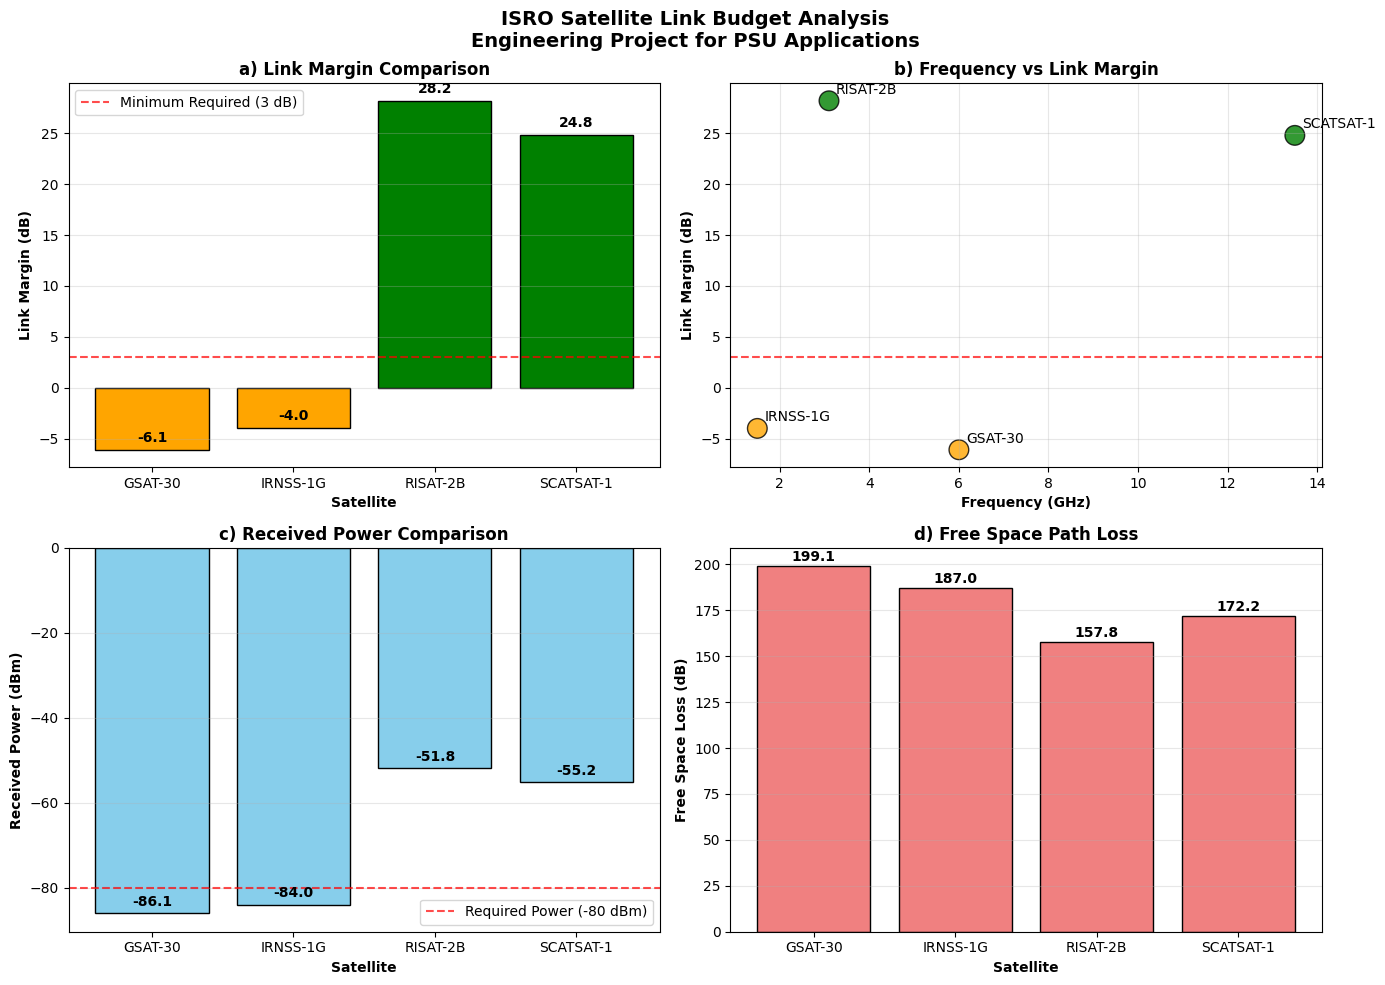

In [26]:
# Cell 8: Visualizations

import matplotlib.pyplot as plt
import numpy as np

print("📈 GENERATING VISUALIZATIONS...")

# Prepare data for plotting
names = [r['name'] for r in all_results]
margins = [r['link_margin_dB'] for r in all_results]
freqs = [r['frequency_GHz'] for r in all_results]
colors = ['green' if r['feasible'] == 'YES' else 'orange' for r in all_results]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ISRO Satellite Link Budget Analysis\nEngineering Project for PSU Applications', 
             fontsize=14, fontweight='bold')

# Plot 1: Link Margin Comparison
ax1 = axes[0, 0]
bars = ax1.bar(names, margins, color=colors, edgecolor='black')
ax1.axhline(y=3, color='red', linestyle='--', alpha=0.7, label='Minimum Required (3 dB)')
ax1.set_xlabel('Satellite', fontweight='bold')
ax1.set_ylabel('Link Margin (dB)', fontweight='bold')
ax1.set_title('a) Link Margin Comparison', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Frequency vs Link Margin
ax2 = axes[0, 1]
scatter = ax2.scatter(freqs, margins, s=200, c=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=3, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Frequency (GHz)', fontweight='bold')
ax2.set_ylabel('Link Margin (dB)', fontweight='bold')
ax2.set_title('b) Frequency vs Link Margin', fontweight='bold')
ax2.grid(True, alpha=0.3)
# Annotate points
for i, (name, freq, margin) in enumerate(zip(names, freqs, margins)):
    ax2.annotate(name, (freq, margin), xytext=(5, 5), textcoords='offset points')

# Plot 3: Received Power
ax3 = axes[1, 0]
rx_powers = [r['received_power_dBm'] for r in all_results]
bars3 = ax3.bar(names, rx_powers, color='skyblue', edgecolor='black')
ax3.axhline(y=-80, color='red', linestyle='--', alpha=0.7, label='Required Power (-80 dBm)')
ax3.set_xlabel('Satellite', fontweight='bold')
ax3.set_ylabel('Received Power (dBm)', fontweight='bold')
ax3.set_title('c) Received Power Comparison', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend()
# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Free Space Loss
ax4 = axes[1, 1]
fspl_values = [r['free_space_loss_dB'] for r in all_results]
bars4 = ax4.bar(names, fspl_values, color='lightcoral', edgecolor='black')
ax4.set_xlabel('Satellite', fontweight='bold')
ax4.set_ylabel('Free Space Loss (dB)', fontweight='bold')
ax4.set_title('d) Free Space Path Loss', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
# Add value labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('isro_satellite_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualizations saved as 'isro_satellite_analysis.png'")
plt.show()

In [29]:
# Cell 9: Project Summary and Applications

print("="*70)
print("🎯 PROJECT SUMMARY: ISRO SATELLITE LINK BUDGET ANALYSIS")
print("="*70)

print("""
📌 WHAT THIS PROJECT DEMONSTRATES:

1. ✅ PHYSICS UNDERSTANDING:
   • Free Space Path Loss calculations
   • dB/dBm/dBi concepts in RF communications
   • Satellite communication fundamentals

2. ✅ ENGINEERING SKILLS:
   • Link budget analysis for satellite systems
   • Parameter optimization for link improvement
   • System feasibility assessment

3. ✅ PROGRAMMING SKILLS:
   • Python implementation of engineering equations
   • Data analysis and visualization
   • Professional code organization

4. ✅ RELEVANCE TO ISRO/PSU WORK:
   • Actual engineering task performed at ISRO
   • Understanding of satellite communication parameters
   • Ability to analyze and improve system performance

🔧 TECHNICAL ACHIEVEMENTS:
• Implemented correct free space path loss equation
• Analyzed 4 different ISRO satellites
• Identified marginal links and suggested improvements
• Created professional visualizations""")

🎯 PROJECT SUMMARY: ISRO SATELLITE LINK BUDGET ANALYSIS

📌 WHAT THIS PROJECT DEMONSTRATES:

1. ✅ PHYSICS UNDERSTANDING:
   • Free Space Path Loss calculations
   • dB/dBm/dBi concepts in RF communications
   • Satellite communication fundamentals

2. ✅ ENGINEERING SKILLS:
   • Link budget analysis for satellite systems
   • Parameter optimization for link improvement
   • System feasibility assessment

3. ✅ PROGRAMMING SKILLS:
   • Python implementation of engineering equations
   • Data analysis and visualization
   • Professional code organization

4. ✅ RELEVANCE TO ISRO/PSU WORK:
   • Actual engineering task performed at ISRO
   • Understanding of satellite communication parameters
   • Ability to analyze and improve system performance

🔧 TECHNICAL ACHIEVEMENTS:
• Implemented correct free space path loss equation
• Analyzed 4 different ISRO satellites
• Identified marginal links and suggested improvements
• Created professional visualizations
